# ✈️ British Airways – Task 2: Predicting Customer Buying Behaviour

**Goal:** Build a Random Forest classifier to predict whether a customer will complete a booking, then interpret which features drive that prediction.

---
### Notebook Structure
1. Install & Import Libraries  
2. Load Data  
3. Exploratory Data Analysis (EDA)  
4. Data Preparation & Feature Engineering  
5. Train Random Forest Model  
6. Cross-Validation & Evaluation Metrics  
7. Feature Importance Visualisation  
8. Summary of Findings

---
## 1. Install & Import Libraries

In [9]:
# Install any missing packages (uncomment if needed)
# !pip install scikit-learn matplotlib seaborn pandas numpy

In [10]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


---
## 2. Load the Data

In [11]:
# Load the customer booking CSV
# encoding='latin1' is required because some booking_origin values contain special characters
df = pd.read_csv('customer_booking.csv', encoding='latin1')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 50,000 rows × 14 columns


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [12]:
# Column names, data types, and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [13]:
# Summary statistics for numeric columns
df.describe().round(2)

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,1.59,84.94,23.04,9.07,0.67,0.30,0.43,7.28,0.15
std,1.02,90.45,33.89,5.41,0.47,0.46,0.49,1.50,0.36
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,4.67,0.00
25%,1.00,21.00,5.00,5.00,0.00,0.00,0.00,5.62,0.00
50%,1.00,51.00,17.00,9.00,1.00,0.00,0.00,7.57,0.00
75%,2.00,115.00,28.00,13.00,1.00,1.00,1.00,8.83,0.00
max,9.00,867.00,778.00,23.00,1.00,1.00,1.00,9.50,1.00


---
## 3. Exploratory Data Analysis (EDA)

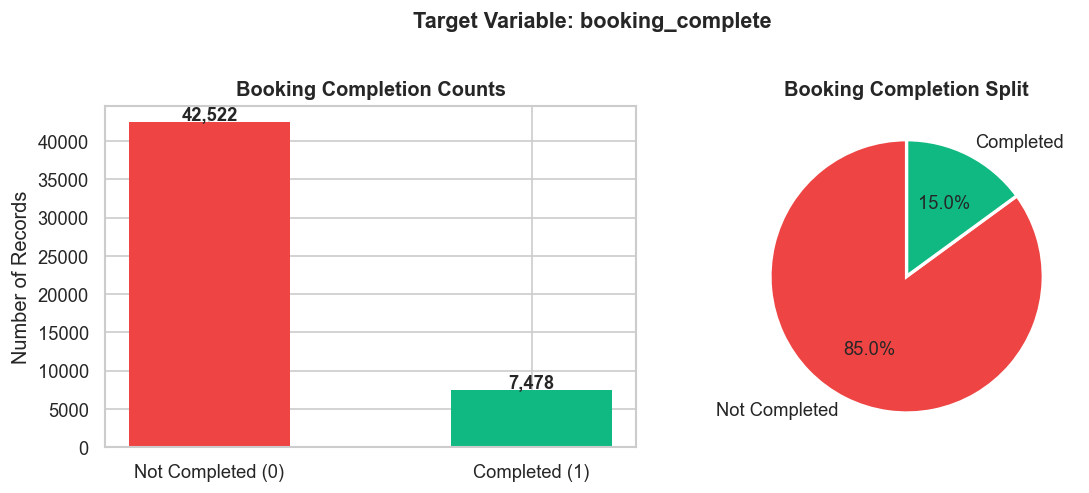


⚠️  Class Imbalance: Only 15.0% of customers complete a booking.
   → We will use class_weight="balanced" in the model to handle this.


In [14]:
# ── Target variable distribution ──────────────────────────────────────────────
# booking_complete: 0 = not completed, 1 = completed
counts = df['booking_complete'].value_counts()
pct    = df['booking_complete'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['Not Completed (0)', 'Completed (1)'], counts.values,
            color=['#EF4444', '#10B981'], edgecolor='none', width=0.5)
axes[0].set_title('Booking Completion Counts', fontweight='bold')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Not Completed', 'Completed'],
            autopct='%1.1f%%', colors=['#EF4444', '#10B981'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Booking Completion Split', fontweight='bold')

plt.suptitle('Target Variable: booking_complete', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n⚠️  Class Imbalance: Only {pct[1]:.1f}% of customers complete a booking.')
print('   → We will use class_weight="balanced" in the model to handle this.')

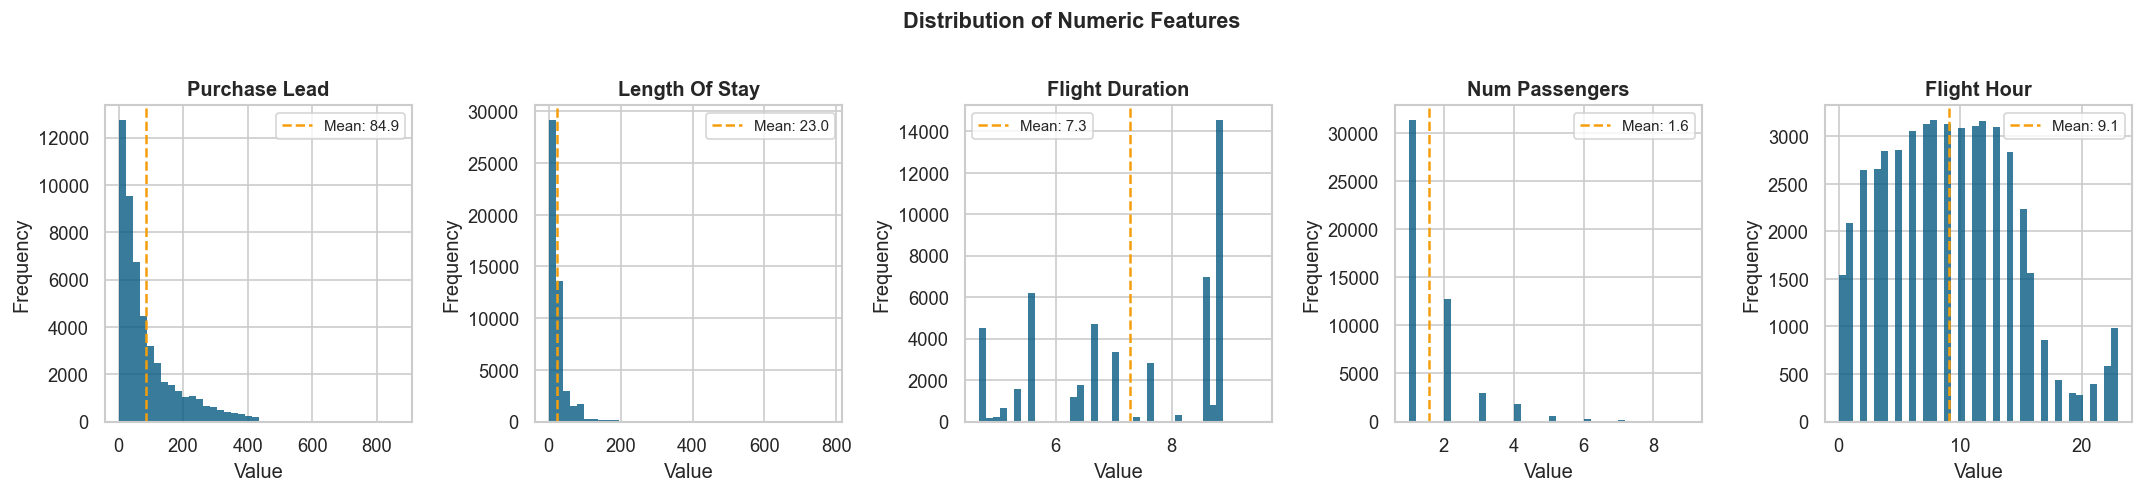

In [15]:
# ── Distribution of numeric features ─────────────────────────────────────────
numeric_cols = ['purchase_lead', 'length_of_stay', 'flight_duration',
                'num_passengers', 'flight_hour']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=40, color='#065A82', alpha=0.8, edgecolor='none')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#F59E0B', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Numeric Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

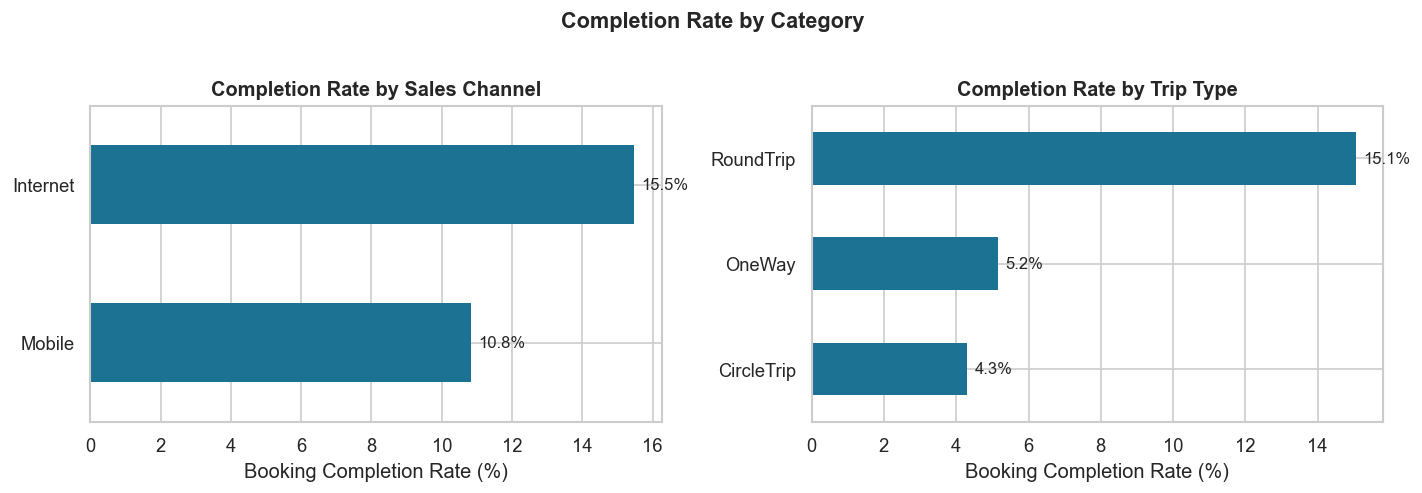

In [16]:
# ── Categorical features vs booking completion ────────────────────────────────
cat_cols = ['sales_channel', 'trip_type']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, cat_cols):
    ct = df.groupby(col)['booking_complete'].mean() * 100  # completion rate %
    ct.sort_values().plot(kind='barh', ax=ax, color='#1C7293', edgecolor='none')
    ax.set_title(f'Completion Rate by {col.replace("_"," ").title()}', fontweight='bold')
    ax.set_xlabel('Booking Completion Rate (%)')
    ax.set_ylabel('')
    for i, v in enumerate(ct.sort_values()):
        ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('Completion Rate by Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

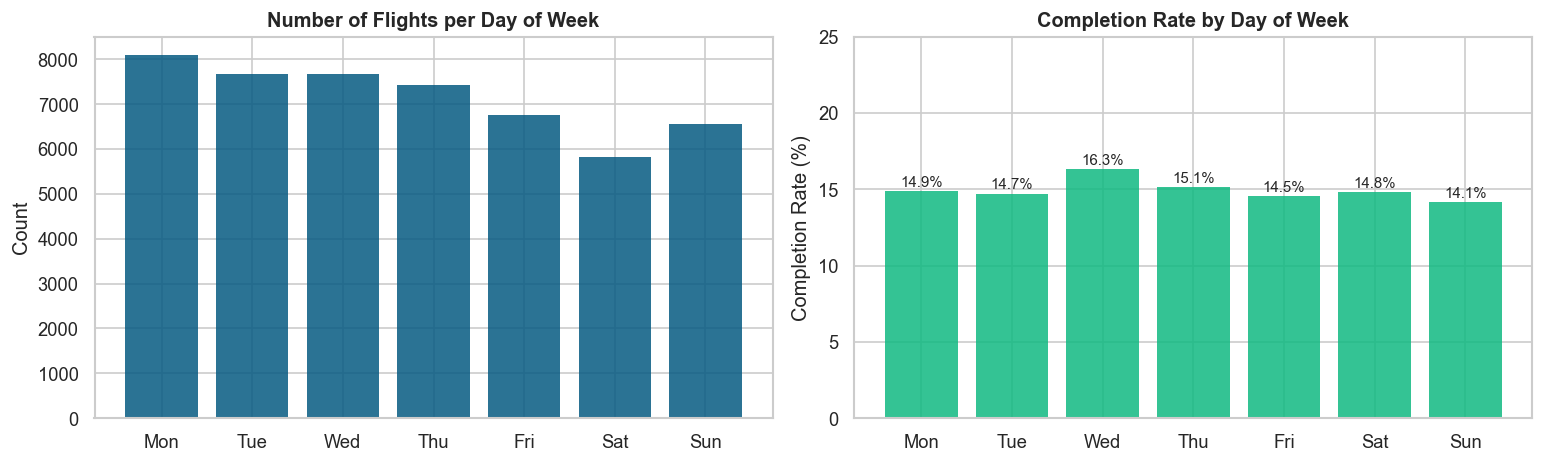

In [17]:
# ── Flight day distribution ───────────────────────────────────────────────────
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['flight_day'].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Flight counts by day
axes[0].bar(day_order, day_counts.values, color='#065A82', alpha=0.85, edgecolor='none')
axes[0].set_title('Number of Flights per Day of Week', fontweight='bold')
axes[0].set_ylabel('Count')

# Completion rate by day
day_complete = df.groupby('flight_day')['booking_complete'].mean().reindex(day_order) * 100
axes[1].bar(day_order, day_complete.values, color='#10B981', alpha=0.85, edgecolor='none')
axes[1].set_title('Completion Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Completion Rate (%)')
axes[1].set_ylim(0, 25)
for i, v in enumerate(day_complete.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

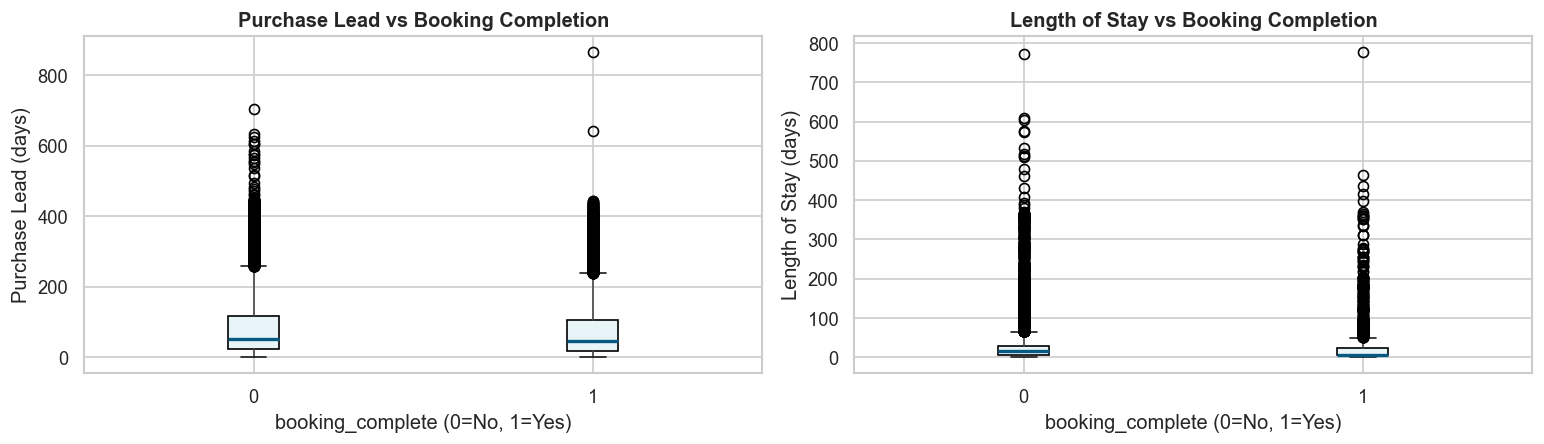

In [18]:
# ── Purchase lead vs booking completion (box plot) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot
df.boxplot(column='purchase_lead', by='booking_complete', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#E8F4F8'),
           medianprops=dict(color='#065A82', linewidth=2))
axes[0].set_title('Purchase Lead vs Booking Completion', fontweight='bold')
axes[0].set_xlabel('booking_complete (0=No, 1=Yes)')
axes[0].set_ylabel('Purchase Lead (days)')
plt.sca(axes[0])
plt.title('Purchase Lead vs Booking Completion', fontweight='bold')

# Length of stay box plot
df.boxplot(column='length_of_stay', by='booking_complete', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#E8F4F8'),
           medianprops=dict(color='#065A82', linewidth=2))
axes[1].set_title('Length of Stay vs Booking Completion', fontweight='bold')
axes[1].set_xlabel('booking_complete (0=No, 1=Yes)')
axes[1].set_ylabel('Length of Stay (days)')
plt.sca(axes[1])
plt.title('Length of Stay vs Booking Completion', fontweight='bold')

plt.suptitle('')   # remove auto title from boxplot
plt.tight_layout()
plt.show()

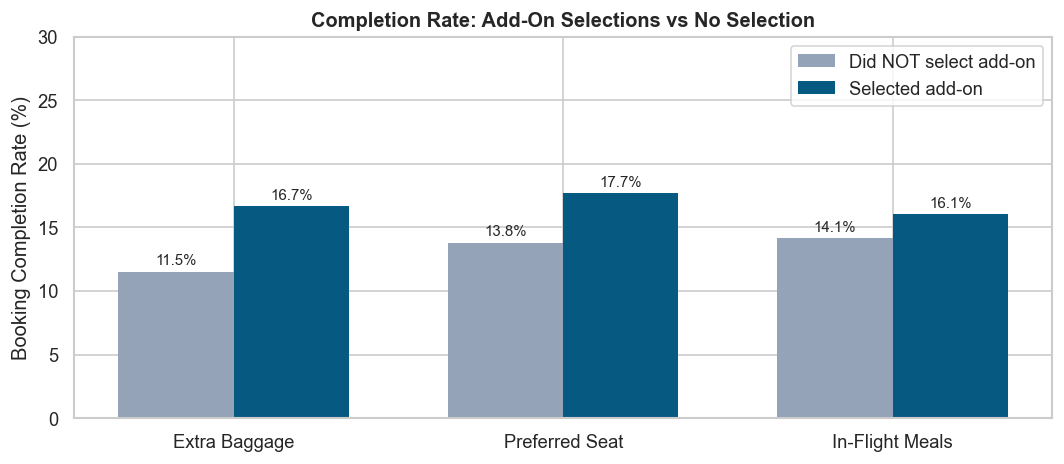


💡 Customers who select add-ons have a noticeably higher completion rate — a strong intent signal.


In [19]:
# ── Add-on selections vs completion ──────────────────────────────────────────
extras = ['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']
extra_labels = ['Extra Baggage', 'Preferred Seat', 'In-Flight Meals']

rates_yes = [df[df[e]==1]['booking_complete'].mean()*100 for e in extras]
rates_no  = [df[df[e]==0]['booking_complete'].mean()*100 for e in extras]

x = np.arange(len(extras))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, rates_no,  width, label='Did NOT select add-on', color='#94A3B8', edgecolor='none')
b2 = ax.bar(x + width/2, rates_yes, width, label='Selected add-on',        color='#065A82', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(extra_labels)
ax.set_ylabel('Booking Completion Rate (%)')
ax.set_title('Completion Rate: Add-On Selections vs No Selection', fontweight='bold')
ax.legend()
ax.set_ylim(0, 30)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print('\n💡 Customers who select add-ons have a noticeably higher completion rate — a strong intent signal.')

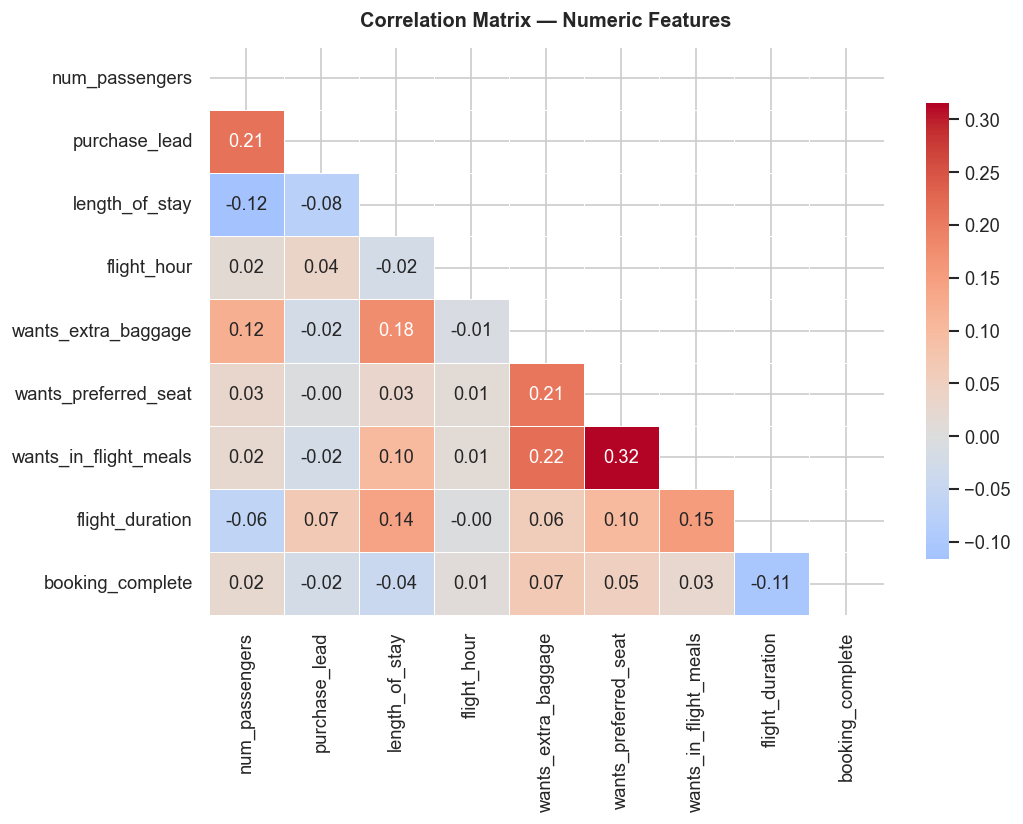

In [20]:
# ── Correlation heatmap (numeric features) ────────────────────────────────────
num_df = df.select_dtypes(include='number')

# Map flight_day to numbers first for correlation
day_map = {'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat':6,'Sun':7}
num_df = num_df.copy()

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 4. Data Preparation & Feature Engineering

In [21]:
# ── Step 1: Encode flight_day (Mon–Sun → 1–7) ─────────────────────────────────
day_map = {'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat':6,'Sun':7}
df['flight_day'] = df['flight_day'].map(day_map)

print('flight_day unique values after encoding:', sorted(df['flight_day'].unique()))

flight_day unique values after encoding: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [22]:
# ── Step 2: Label-encode categorical columns ───────────────────────────────────
# We use LabelEncoder so the RandomForest can process text values as integers
le = LabelEncoder()

df['sales_channel_enc']  = le.fit_transform(df['sales_channel'])
df['trip_type_enc']      = le.fit_transform(df['trip_type'])
df['booking_origin_enc'] = le.fit_transform(df['booking_origin'])
df['route_enc']          = le.fit_transform(df['route'])

print('Encoded columns added:')
for col in ['sales_channel_enc','trip_type_enc','booking_origin_enc','route_enc']:
    print(f'  {col}: {df[col].nunique()} unique values')

Encoded columns added:
  sales_channel_enc: 2 unique values
  trip_type_enc: 3 unique values
  booking_origin_enc: 104 unique values
  route_enc: 799 unique values


In [23]:
# ── Step 3: Feature Engineering — create 4 new features ───────────────────────

# Feature 1: total_extras
# Customers who select multiple add-ons show stronger booking intent
df['total_extras'] = df['wants_extra_baggage'] + df['wants_preferred_seat'] + df['wants_in_flight_meals']

# Feature 2: is_weekend_flight
# Weekend flights may attract more leisure travellers with different booking patterns
df['is_weekend_flight'] = (df['flight_day'] >= 6).astype(int)

# Feature 3: is_long_haul
# Long-haul flights (> 6 hours) may be planned more in advance and have different completion rates
df['is_long_haul'] = (df['flight_duration'] > 6).astype(int)

# Feature 4: booking_lead_bin
# Bucket purchase_lead into 4 groups: last-minute (0-7), short (7-30), medium (30-90), advance (90+)
df['booking_lead_bin'] = np.digitize(df['purchase_lead'], bins=[7, 30, 90])

print('New features added:')
print(df[['total_extras','is_weekend_flight','is_long_haul','booking_lead_bin']].describe().round(2))

New features added:
       total_extras  is_weekend_flight  is_long_haul  booking_lead_bin
count      50000.00           50000.00      50000.00          50000.00
mean           1.39               0.25          0.73              1.90
std            1.00               0.43          0.44              0.95
min            0.00               0.00          0.00              0.00
25%            1.00               0.00          0.00              1.00
50%            1.00               0.00          1.00              2.00
75%            2.00               0.00          1.00              3.00
max            3.00               1.00          1.00              3.00


In [24]:
# ── Step 4: Define feature matrix X and target y ─────────────────────────────
FEATURES = [
    'num_passengers',        # how many people travelling together
    'purchase_lead',         # days between booking and travel date
    'length_of_stay',        # nights at destination
    'flight_hour',           # departure hour (0-23)
    'flight_day',            # day of week (1=Mon … 7=Sun)
    'wants_extra_baggage',   # add-on: extra baggage (0/1)
    'wants_preferred_seat',  # add-on: preferred seat (0/1)
    'wants_in_flight_meals', # add-on: in-flight meals (0/1)
    'flight_duration',       # total flight hours
    'sales_channel_enc',     # how booking was made (encoded)
    'trip_type_enc',         # round trip / one way / circle (encoded)
    'booking_origin_enc',    # country of booking origin (encoded)
    'route_enc',             # specific flight route (encoded)
    'total_extras',          # ★ engineered: sum of all add-ons
    'is_weekend_flight',     # ★ engineered: 1 if Sat or Sun
    'is_long_haul',          # ★ engineered: 1 if duration > 6 hrs
    'booking_lead_bin',      # ★ engineered: lead time bucket (0–3)
]

X = df[FEATURES]            # feature matrix
y = df['booking_complete']  # target variable

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Feature matrix shape: (50000, 17)
Target distribution:
booking_complete
0    42522
1     7478
Name: count, dtype: int64


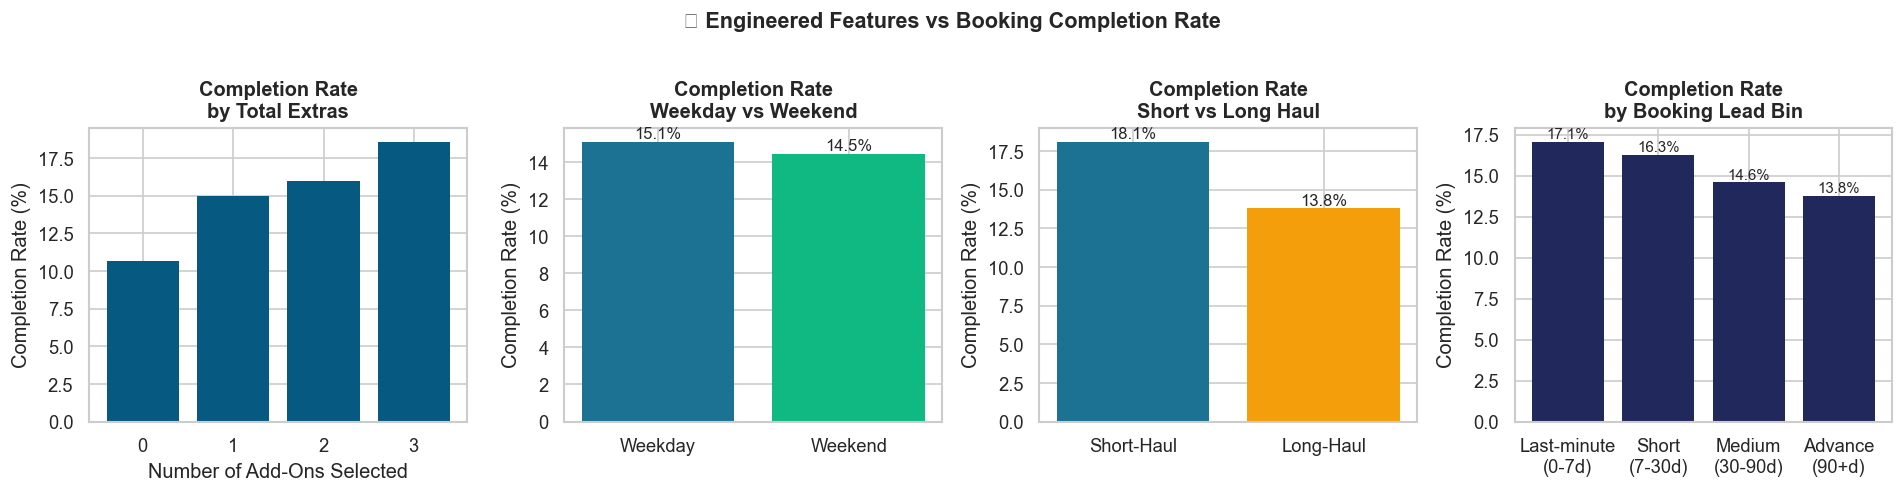

In [25]:
# ── Visualise the 4 engineered features ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# total_extras
extras_rate = df.groupby('total_extras')['booking_complete'].mean() * 100
axes[0].bar(extras_rate.index.astype(str), extras_rate.values, color='#065A82', edgecolor='none')
axes[0].set_title('Completion Rate\nby Total Extras', fontweight='bold')
axes[0].set_xlabel('Number of Add-Ons Selected')
axes[0].set_ylabel('Completion Rate (%)')

# is_weekend_flight
wk_rate = df.groupby('is_weekend_flight')['booking_complete'].mean() * 100
axes[1].bar(['Weekday', 'Weekend'], wk_rate.values, color=['#1C7293','#10B981'], edgecolor='none')
axes[1].set_title('Completion Rate\nWeekday vs Weekend', fontweight='bold')
axes[1].set_ylabel('Completion Rate (%)')
for i, v in enumerate(wk_rate.values):
    axes[1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=10)

# is_long_haul
lh_rate = df.groupby('is_long_haul')['booking_complete'].mean() * 100
axes[2].bar(['Short-Haul', 'Long-Haul'], lh_rate.values, color=['#1C7293','#F59E0B'], edgecolor='none')
axes[2].set_title('Completion Rate\nShort vs Long Haul', fontweight='bold')
axes[2].set_ylabel('Completion Rate (%)')
for i, v in enumerate(lh_rate.values):
    axes[2].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=10)

# booking_lead_bin
bl_rate = df.groupby('booking_lead_bin')['booking_complete'].mean() * 100
bl_labels = ['Last-minute\n(0-7d)', 'Short\n(7-30d)', 'Medium\n(30-90d)', 'Advance\n(90+d)']
axes[3].bar(bl_labels, bl_rate.values, color='#21295C', edgecolor='none')
axes[3].set_title('Completion Rate\nby Booking Lead Bin', fontweight='bold')
axes[3].set_ylabel('Completion Rate (%)')
for i, v in enumerate(bl_rate.values):
    axes[3].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('★ Engineered Features vs Booking Completion Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Train Random Forest Model

In [26]:
# ── Instantiate Random Forest ─────────────────────────────────────────────────
# Why Random Forest?
# - Handles both numeric and encoded categorical features well
# - Provides built-in feature importances
# - Robust to outliers and does not require feature scaling
# - Reduces overfitting via ensemble averaging

rf = RandomForestClassifier(
    n_estimators=200,         # 200 decision trees in the forest
    max_depth=12,             # max depth per tree — controls overfitting
    min_samples_leaf=10,      # each leaf must have ≥10 samples — prevents overfitting
    class_weight='balanced',  # compensate for 85%/15% class imbalance
    random_state=42,          # reproducibility
    n_jobs=-1                 # use all CPU cores
)

print('Random Forest model configured:')
print(rf)

Random Forest model configured:
RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=10, n_estimators=200, n_jobs=-1,
                       random_state=42)


In [27]:
# ── Fit the model on the full dataset ────────────────────────────────────────
# We fit on all data here to extract feature importances across the full sample.
# Performance evaluation is done separately via cross-validation (next section).
rf.fit(X, y)

print(f'Model trained on {X.shape[0]:,} rows with {X.shape[1]} features ✅')

Model trained on 50,000 rows with 17 features ✅


---
## 6. Cross-Validation & Evaluation Metrics

In [28]:
# ── 5-Fold Stratified Cross-Validation ───────────────────────────────────────
# Stratified: ensures each fold has the same class ratio as the full dataset
# This gives a more honest estimate of model performance than a single train/test split

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf, X, y,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=False,
    n_jobs=-1
)

print('=' * 50)
print('   5-Fold Cross-Validation Results')
print('=' * 50)
metric_names = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']
for m in metric_names:
    vals = cv_results[f'test_{m}']
    print(f'  {m:12s}:  {vals.mean():.4f}  ±  {vals.std():.4f}')
print('=' * 50)

   5-Fold Cross-Validation Results
  accuracy    :  0.7307  ±  0.0031
  roc_auc     :  0.7715  ±  0.0043
  precision   :  0.3112  ±  0.0024
  recall      :  0.6594  ±  0.0110
  f1          :  0.4228  ±  0.0034


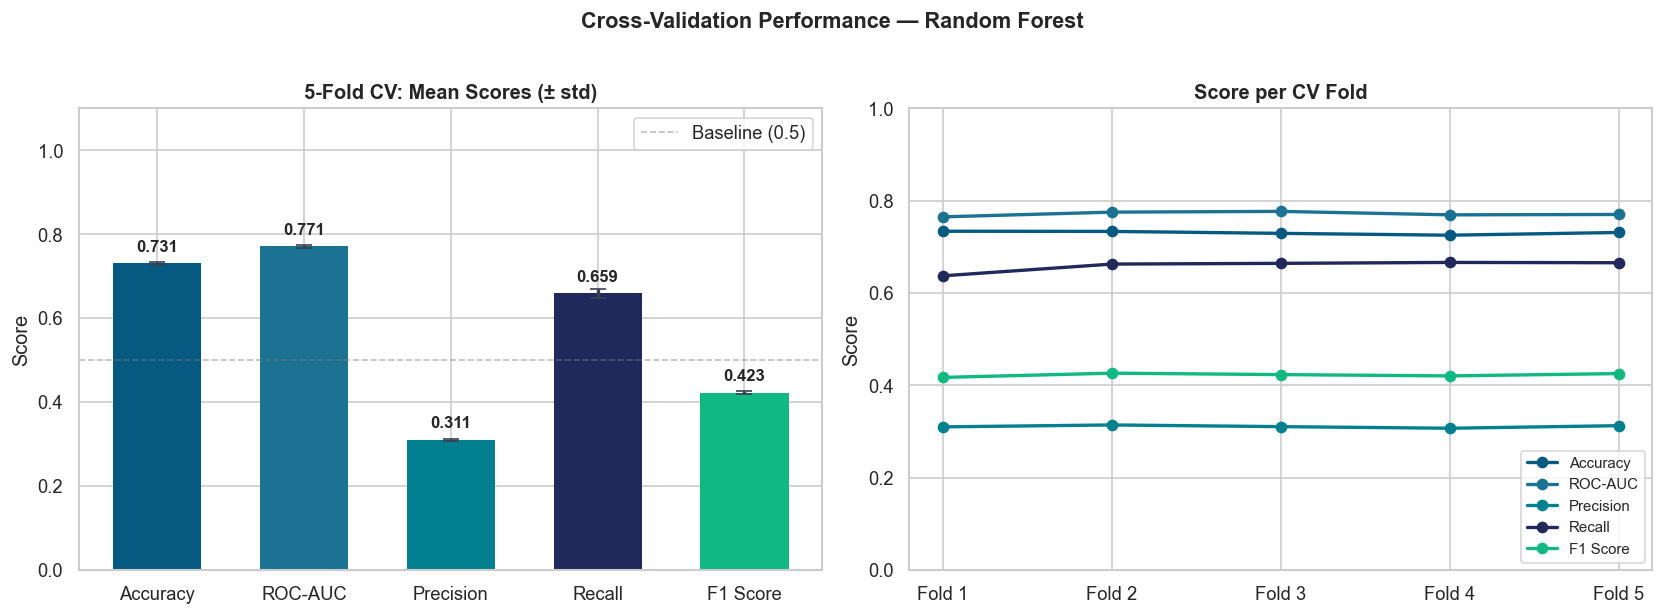

In [29]:
# ── Plot CV metric scores across folds ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─ Left: Mean scores bar chart with error bars ─
means = [cv_results[f'test_{m}'].mean() for m in metric_names]
stds  = [cv_results[f'test_{m}'].std()  for m in metric_names]
colors = ['#065A82', '#1C7293', '#028090', '#21295C', '#10B981']
labels = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1 Score']

bars = axes[0].bar(labels, means, color=colors, edgecolor='none', width=0.6)
axes[0].errorbar(labels, means, yerr=stds, fmt='none', color='#374151', capsize=5, linewidth=2)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('5-Fold CV: Mean Scores (± std)', fontweight='bold')
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, m+0.02, f'{m:.3f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Baseline (0.5)')
axes[0].legend()

# ─ Right: Per-fold scores line chart ─
fold_x = [1, 2, 3, 4, 5]
for m, col, lbl in zip(metric_names, colors, labels):
    fold_scores = cv_results[f'test_{m}']
    axes[1].plot(fold_x, fold_scores, marker='o', color=col, label=lbl, linewidth=2)

axes[1].set_xticks(fold_x)
axes[1].set_xticklabels([f'Fold {i}' for i in fold_x])
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Score per CV Fold', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle('Cross-Validation Performance — Random Forest', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

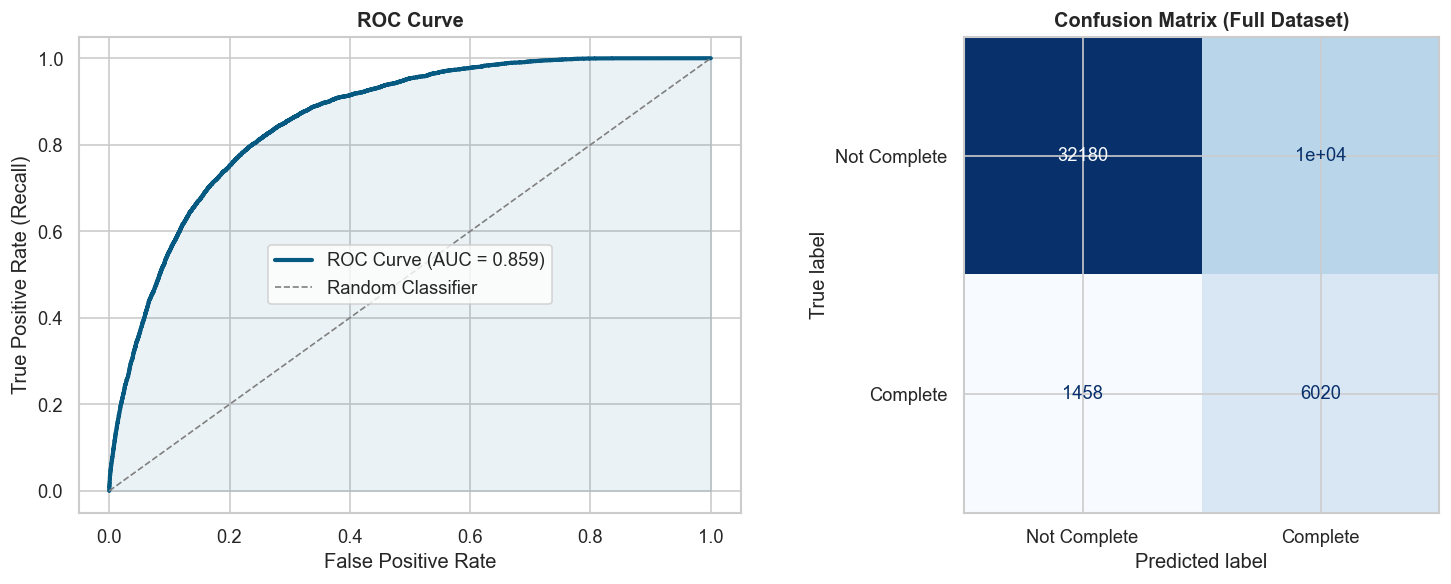


Classification Report:
              precision    recall  f1-score   support

Not Complete       0.96      0.76      0.85     42522
    Complete       0.37      0.81      0.51      7478

    accuracy                           0.76     50000
   macro avg       0.66      0.78      0.68     50000
weighted avg       0.87      0.76      0.79     50000



In [30]:
# ── ROC Curve & Confusion Matrix ──────────────────────────────────────────────
# Use predictions on the full dataset (fitted model) for illustration
y_pred      = rf.predict(X)
y_pred_prob = rf.predict_proba(X)[:, 1]  # probability of class 1

fpr, tpr, _ = roc_curve(y, y_pred_prob)
auc_score   = roc_auc_score(y, y_pred_prob)
cm          = confusion_matrix(y, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='#065A82', linewidth=2.5, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#065A82')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Complete', 'Complete'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Full Dataset)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y, y_pred, target_names=['Not Complete', 'Complete']))

---
## 7. Feature Importance Visualisation

In [31]:
# ── Extract and sort feature importances ──────────────────────────────────────
# Random Forest measures importance as mean decrease in impurity (Gini importance)
# Higher value = more important for predicting the target

FEATURE_LABELS = {
    'num_passengers':        'No. Passengers',
    'purchase_lead':         'Purchase Lead (days)',
    'length_of_stay':        'Length of Stay',
    'flight_hour':           'Flight Hour',
    'flight_day':            'Flight Day',
    'wants_extra_baggage':   'Extra Baggage',
    'wants_preferred_seat':  'Preferred Seat',
    'wants_in_flight_meals': 'In-Flight Meals',
    'flight_duration':       'Flight Duration',
    'sales_channel_enc':     'Sales Channel',
    'trip_type_enc':         'Trip Type',
    'booking_origin_enc':    'Booking Origin',
    'route_enc':             'Route',
    'total_extras':          '★ Total Extras (engineered)',
    'is_weekend_flight':     '★ Weekend Flight (engineered)',
    'is_long_haul':          '★ Long Haul (engineered)',
    'booking_lead_bin':      '★ Booking Lead Bin (engineered)',
}

importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances.index = [FEATURE_LABELS[f] for f in importances.index]
importances = importances.sort_values(ascending=False)

print('Feature Importances (all features):')
for feat, imp in importances.items():
    bar = '█' * int(imp * 100)
    print(f'  {feat:35s}  {imp:.4f}  {bar}')

Feature Importances (all features):
  Booking Origin                       0.3330  █████████████████████████████████
  Route                                0.1453  ██████████████
  Length of Stay                       0.1096  ██████████
  Flight Duration                      0.0941  █████████
  Purchase Lead (days)                 0.0813  ████████
  Flight Hour                          0.0535  █████
  ★ Total Extras (engineered)          0.0335  ███
  Flight Day                           0.0319  ███
  Extra Baggage                        0.0231  ██
  Sales Channel                        0.0189  █
  ★ Booking Lead Bin (engineered)      0.0176  █
  No. Passengers                       0.0175  █
  Preferred Seat                       0.0132  █
  ★ Long Haul (engineered)             0.0094  
  In-Flight Meals                      0.0091  
  ★ Weekend Flight (engineered)        0.0065  
  Trip Type                            0.0024  


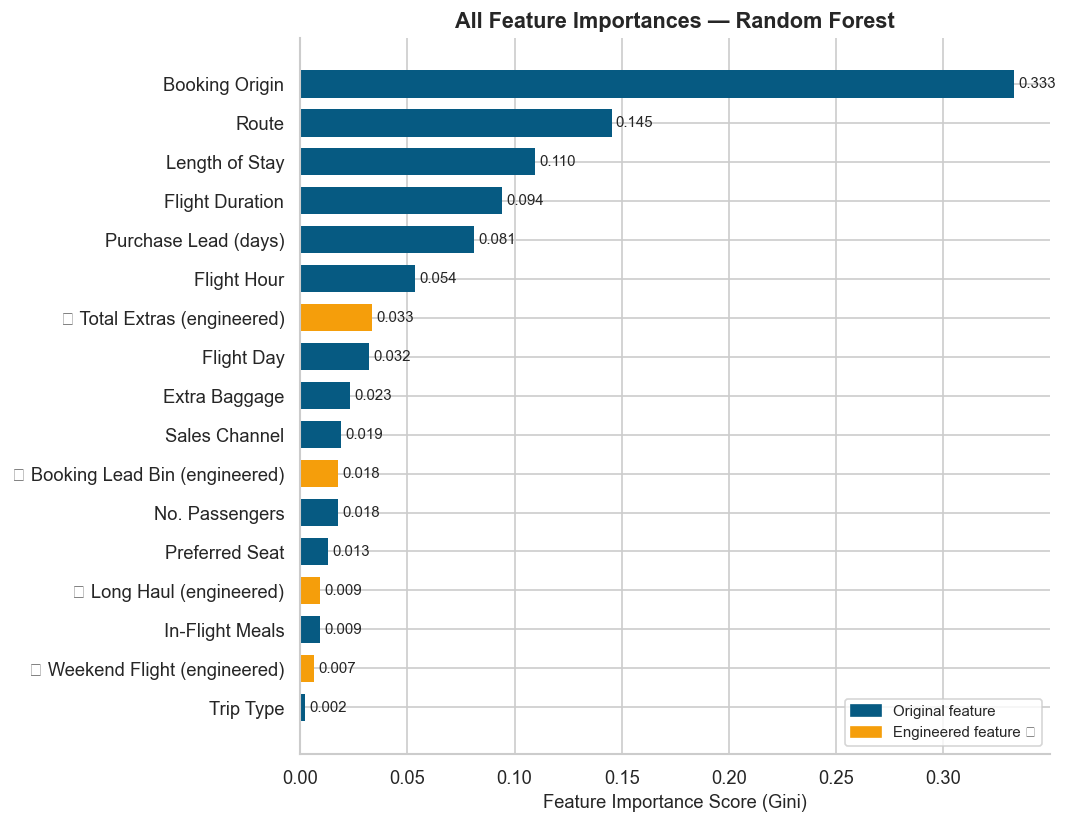

In [32]:
# ── Full feature importance bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# colour engineered features differently
bar_colors = ['#F59E0B' if '★' in f else '#065A82' for f in importances.index[::-1]]

ax.barh(importances.index[::-1], importances.values[::-1],
        color=bar_colors, edgecolor='none', height=0.7)

ax.set_xlabel('Feature Importance Score (Gini)', fontsize=11)
ax.set_title('All Feature Importances — Random Forest', fontweight='bold', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, (val, name) in enumerate(zip(importances.values[::-1], importances.index[::-1])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

# Legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='#065A82', label='Original feature'),
    mpatches.Patch(color='#F59E0B', label='Engineered feature ★'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

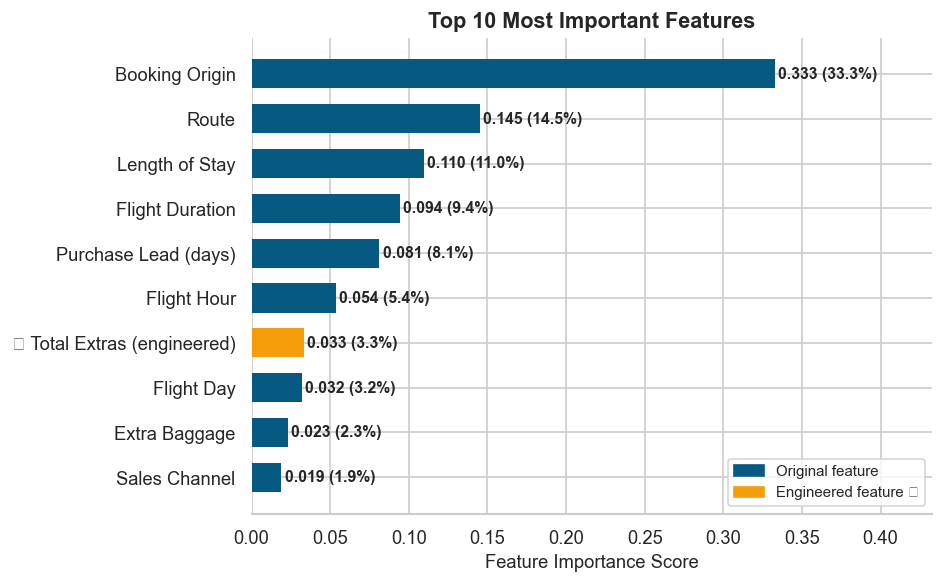

In [33]:
# ── Top 10 feature importances — cleaner view ─────────────────────────────────
top10 = importances.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors_top = ['#F59E0B' if '★' in f else '#065A82' for f in top10.index[::-1]]

bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color=bar_colors_top, edgecolor='none', height=0.65)

ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Top 10 Most Important Features', fontweight='bold', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val + 0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f} ({val*100:.1f}%)', va='center', fontsize=9.5, fontweight='bold')

ax.set_xlim(0, top10.max() * 1.3)
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

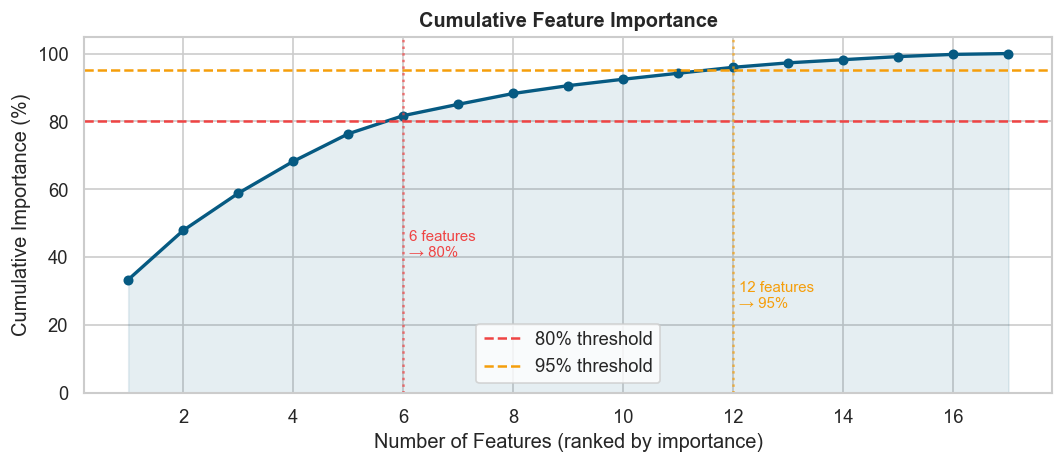

→ 6 features explain 80% of importance
→ 12 features explain 95% of importance


In [34]:
# ── Cumulative importance chart ───────────────────────────────────────────────
# Shows how many features are needed to explain X% of the model's predictive power
cumulative = importances.values.cumsum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumulative)+1), cumulative * 100, marker='o',
        color='#065A82', linewidth=2, markersize=5)
ax.axhline(80, color='#EF4444', linestyle='--', linewidth=1.5, label='80% threshold')
ax.axhline(95, color='#F59E0B', linestyle='--', linewidth=1.5, label='95% threshold')
ax.fill_between(range(1, len(cumulative)+1), cumulative*100, alpha=0.1, color='#065A82')

n80 = next(i+1 for i,v in enumerate(cumulative) if v >= 0.80)
n95 = next(i+1 for i,v in enumerate(cumulative) if v >= 0.95)
ax.axvline(n80, color='#EF4444', linestyle=':', alpha=0.7)
ax.axvline(n95, color='#F59E0B', linestyle=':', alpha=0.7)
ax.text(n80+0.1, 40, f'{n80} features\n→ 80%', fontsize=9, color='#EF4444')
ax.text(n95+0.1, 25, f'{n95} features\n→ 95%', fontsize=9, color='#F59E0B')

ax.set_xlabel('Number of Features (ranked by importance)')
ax.set_ylabel('Cumulative Importance (%)')
ax.set_title('Cumulative Feature Importance', fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print(f'→ {n80} features explain 80% of importance')
print(f'→ {n95} features explain 95% of importance')

---
## 8. Summary of Findings

In [35]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1 Score'],
    'CV Mean': [round(cv_results[f'test_{m}'].mean(), 4) for m in metric_names],
    'CV Std':  [round(cv_results[f'test_{m}'].std(), 4)  for m in metric_names],
})
print('=== Model Performance Summary ===')
print(summary.to_string(index=False))

print('\n=== Top 5 Feature Importances ===')
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f'  {i}. {feat:<35s} {imp:.4f} ({imp*100:.1f}%)')

print('''
=== Interpretation ===
• Booking Origin (33%) is by far the strongest signal — WHERE a customer
  books from is highly predictive of whether they complete a booking.

• Route (15%) reinforces the geographic signal — specific origin-destination
  pairs have very different completion rates.

• Length of Stay (11%) and Flight Duration (9%) capture trip characteristics.
  Longer, more committed trips tend to be completed at higher rates.

• Purchase Lead (8%) indicates planning intent — customers who book further
  in advance are more likely to follow through.

• Model Limitations:
  - Recall (65.9%) is reasonable but Precision (31.1%) is low, meaning
    many false positives. This is expected given the 15% booking rate.
  - Proactive marketing should target customers from high-completion origins
    on popular routes, especially those planning trips with add-ons selected.
''')

=== Model Performance Summary ===
   Metric  CV Mean  CV Std
 Accuracy   0.7307  0.0031
  ROC-AUC   0.7715  0.0043
Precision   0.3112  0.0024
   Recall   0.6594  0.0110
 F1 Score   0.4228  0.0034

=== Top 5 Feature Importances ===
  1. Booking Origin                      0.3330 (33.3%)
  2. Route                               0.1453 (14.5%)
  3. Length of Stay                      0.1096 (11.0%)
  4. Flight Duration                     0.0941 (9.4%)
  5. Purchase Lead (days)                0.0813 (8.1%)

=== Interpretation ===
• Booking Origin (33%) is by far the strongest signal — WHERE a customer
  books from is highly predictive of whether they complete a booking.

• Route (15%) reinforces the geographic signal — specific origin-destination
  pairs have very different completion rates.

• Length of Stay (11%) and Flight Duration (9%) capture trip characteristics.
  Longer, more committed trips tend to be completed at higher rates.

• Purchase Lead (8%) indicates planning intent — cu

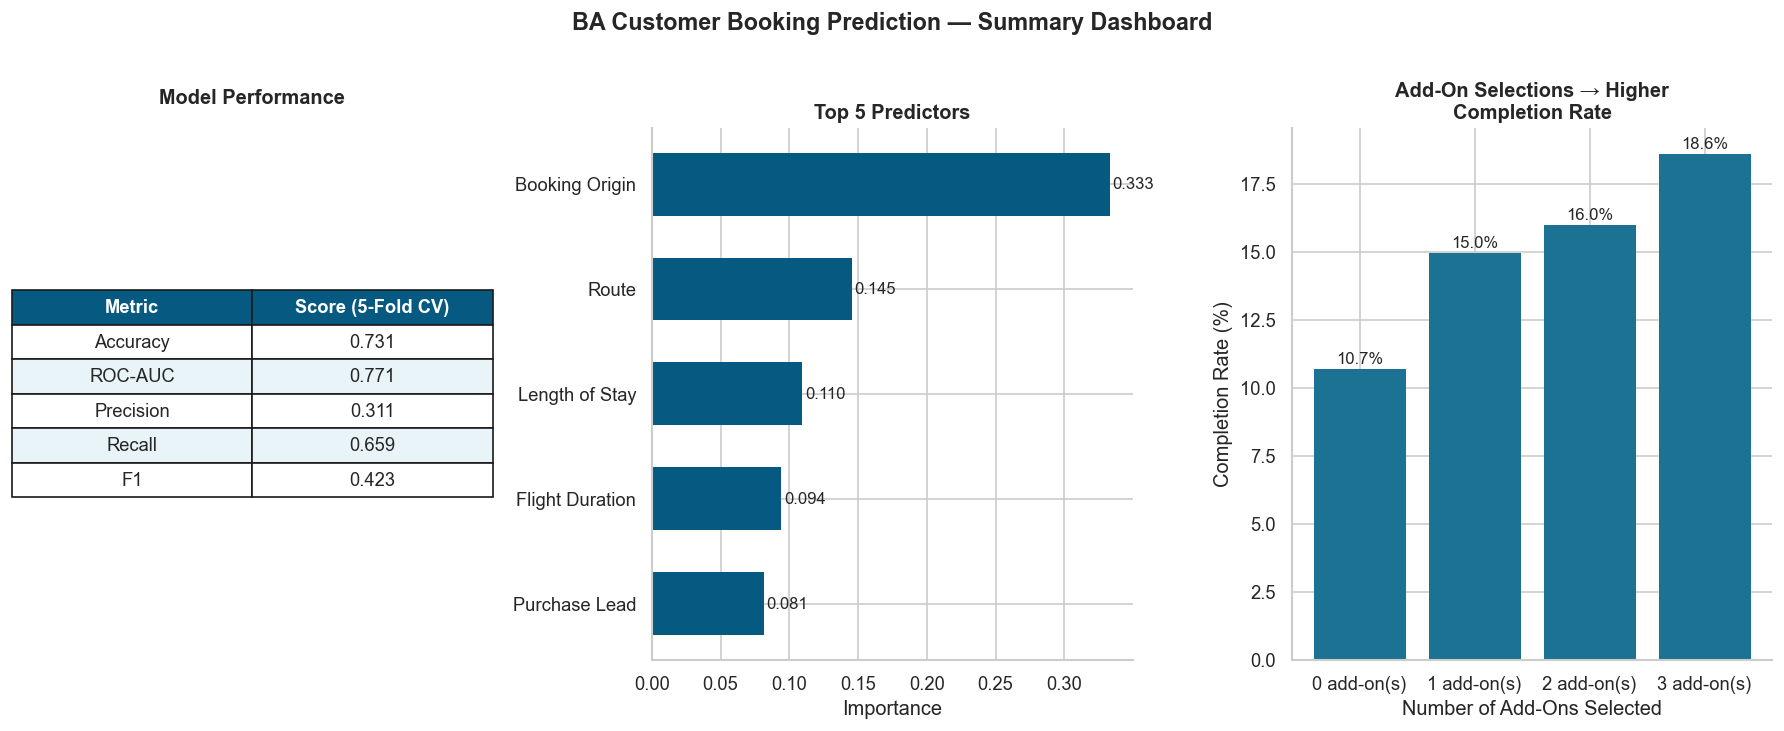


✅ Analysis complete!


In [36]:
# ── Final summary dashboard ───────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6))
fig.suptitle('BA Customer Booking Prediction — Summary Dashboard', fontsize=14, fontweight='bold', y=1.01)

# --- Subplot 1: Metric cards as a table ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.axis('off')
metric_vals = [f"{cv_results[f'test_{m}'].mean():.3f}" for m in metric_names]
table_data  = list(zip(['Accuracy','ROC-AUC','Precision','Recall','F1'], metric_vals))
tbl = ax1.table(cellText=table_data, colLabels=['Metric','Score (5-Fold CV)'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#065A82')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E8F4F8')
ax1.set_title('Model Performance', fontweight='bold', pad=15)

# --- Subplot 2: Top 5 features ---
ax2 = fig.add_subplot(1, 3, 2)
top5 = importances.head(5)
short_labels = [l.replace(' (engineered)','★').replace(' (days)','') for l in top5.index[::-1]]
cols2 = ['#F59E0B' if '★' in l else '#065A82' for l in short_labels]
ax2.barh(short_labels, top5.values[::-1], color=cols2, edgecolor='none', height=0.6)
ax2.set_xlabel('Importance')
ax2.set_title('Top 5 Predictors', fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for i, v in enumerate(top5.values[::-1]):
    ax2.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=10)

# --- Subplot 3: Class balance + booking rate ---
ax3 = fig.add_subplot(1, 3, 3)
booking_by_extras = df.groupby('total_extras')['booking_complete'].mean()*100
ax3.bar([f'{i} add-on(s)' for i in booking_by_extras.index],
        booking_by_extras.values, color='#1C7293', edgecolor='none')
ax3.set_xlabel('Number of Add-Ons Selected')
ax3.set_ylabel('Completion Rate (%)')
ax3.set_title('Add-On Selections → Higher\nCompletion Rate', fontweight='bold')
for i, v in enumerate(booking_by_extras.values):
    ax3.text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('\n✅ Analysis complete!')